# Segmentación de clientes con K-Means

Este cuaderno implementa un flujo completo de segmentación de clientes usando K-Means, desde la exploración de datos hasta una predicción interactiva orientada a negocio.

In [19]:
# Instalación de dependencias (ejecutar solo si hace falta)
%pip install -q pandas numpy matplotlib seaborn scikit-learn joblib kneed streamlit


Note: you may need to restart the kernel to use updated packages.


In [20]:
# Imports centralizados para todo el cuaderno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

import joblib

try:
    from kneed import KneeLocator
    KNEED_AVAILABLE = True
except Exception:
    KNEED_AVAILABLE = False

# Configuración visual consistente
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (9, 5)

# Reproducibilidad global
RANDOM_STATE = 42

## PARTE 1 - Exploración de Datos

In [21]:
# Celda de código 1: Carga del dataset
# Si no existe Mall_Customers.csv, se usa installdataset.py
from pathlib import Path

DATA_PATH = "Mall_Customers.csv"
if not Path(DATA_PATH).exists():
    from installdataset import ensure_mall_customers_csv

    DATA_PATH = str(ensure_mall_customers_csv())

df = pd.read_csv(DATA_PATH)

print("Primeras 10 filas:")
display(df.head(10))

print("Shape del dataset:", df.shape)

print("\nInformación general:")
df.info()

print("\nEstadísticas descriptivas:")
display(df.describe())


Primeras 10 filas:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


Shape del dataset: (200, 5)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Estadísticas descriptivas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Variables numéricas: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Variables categóricas: ['Gender']

Matriz de correlación:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


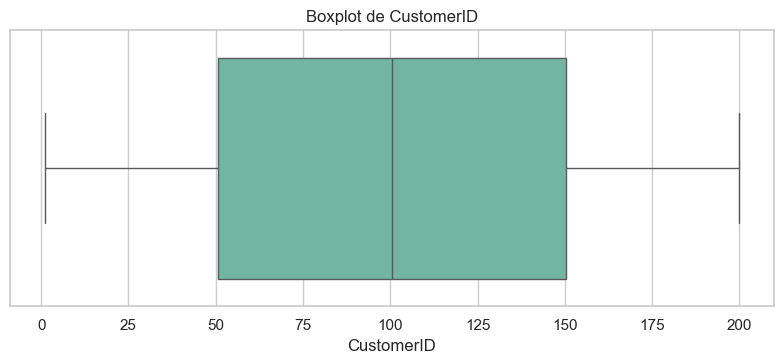

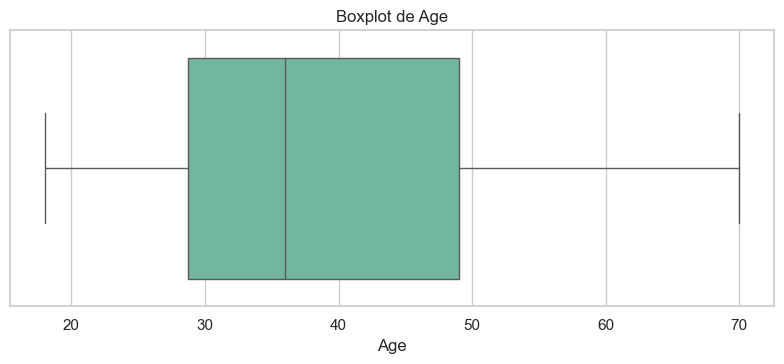

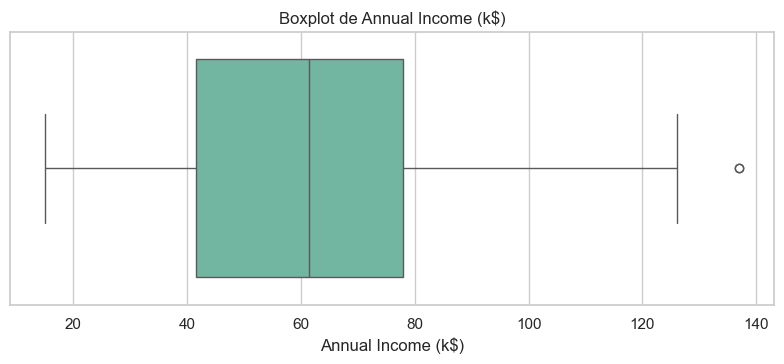

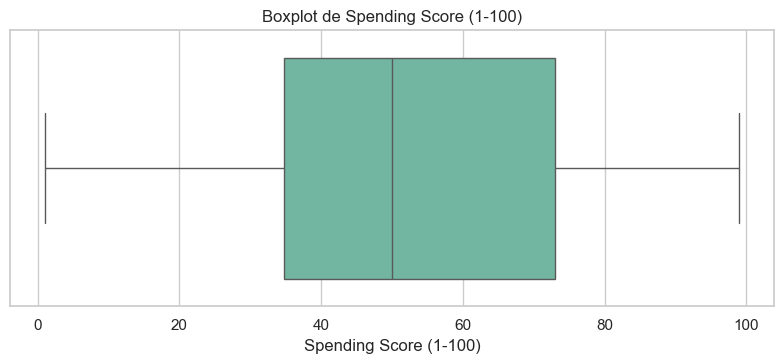

In [22]:
# Celda de código 2: Identificación de variables relevantes
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Variables numéricas:", numeric_cols)
print("Variables categóricas:", categorical_cols)

# Correlación en formato tabla para interpretar relaciones lineales
corr = df[numeric_cols].corr(numeric_only=True)
print("\nMatriz de correlación:")
display(corr)

for col in numeric_cols:
    plt.figure(figsize=(8, 3.8))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


Conteo de outliers por variable (IQR):
- CustomerID: 0
- Age: 0
- Annual Income (k$): 2
- Spending Score (1-100): 0


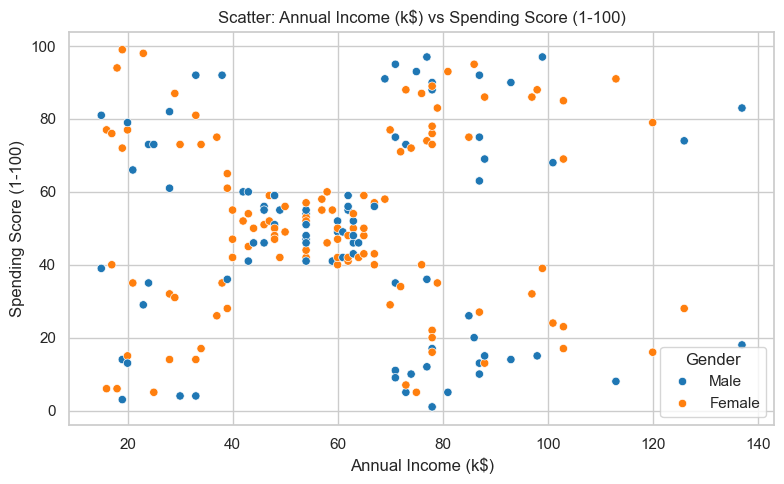

In [23]:
# Celda de código 3: Análisis de valores atípicos (IQR)
outlier_summary = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary[col] = int(mask.sum())

print("Conteo de outliers por variable (IQR):")
for k, v in outlier_summary.items():
    print(f"- {k}: {v}")

candidate_x = "Annual Income (k$)" if "Annual Income (k$)" in df.columns else numeric_cols[0]
candidate_y = "Spending Score (1-100)" if "Spending Score (1-100)" in df.columns else (
    numeric_cols[1] if len(numeric_cols) > 1 else numeric_cols[0]
)

hue_col = categorical_cols[0] if categorical_cols else None
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=candidate_x, y=candidate_y, hue=hue_col, palette="tab10")
plt.title(f"Scatter: {candidate_x} vs {candidate_y}")
plt.xlabel(candidate_x)
plt.ylabel(candidate_y)
if hue_col:
    plt.legend(title=hue_col, loc="best")
plt.tight_layout()
plt.show()


### Respuestas - Parte 1

**1) ¿Qué variables son más adecuadas para segmentar clientes?**  
Las variables más útiles son `Annual Income (k$)` y `Spending Score (1-100)`, porque capturan capacidad económica y comportamiento de consumo. Variables como `Age` o `Gender` pueden complementar el perfil, pero suelen separar menos los grupos de compra en este caso.

**2) ¿Se identifican valores atípicos?**  
Con el método IQR aparecen valores extremos en algunas variables numéricas. No deben eliminarse automáticamente: en segmentación pueden representar nichos reales (por ejemplo, clientes premium). Aun así, como K-Means usa distancia euclidiana, es recomendable validar sensibilidad del modelo ante esos puntos.

**3) ¿Qué relaciones se observan entre variables?**  
La matriz de correlación y el scatter principal muestran que no siempre hay relaciones lineales fuertes, pero sí patrones de agrupación visual entre ingreso y score. Eso respalda el uso de clustering para encontrar segmentos diferenciados.

## PARTE 2 - Preprocesamiento

Variables seleccionadas para clustering: ['Annual Income (k$)', 'Spending Score (1-100)']


Original                                  Escalado  \
  Annual Income (k$) Spending Score (1-100) Annual Income (k$)   
0                 15                     39          -1.738999   
1                 15                     81          -1.738999   
2                 16                      6          -1.700830   
3                 16                     77          -1.700830   
4                 17                     40          -1.662660   
5                 17                     76          -1.662660   
6                 18                      6          -1.624491   
7                 18                     94          -1.624491   
8                 19                      3          -1.586321   
9                 19                     72          -1.586321   

                          
  Spending Score (1-100)  
0              -0.434801  
1               1.195704  
2              -1.715913  
3               1.040418  
4              -0.395980  
5               1.001596  
6              -1.715913  
7               1.700384  
8              -1.832378  
9               0.846310

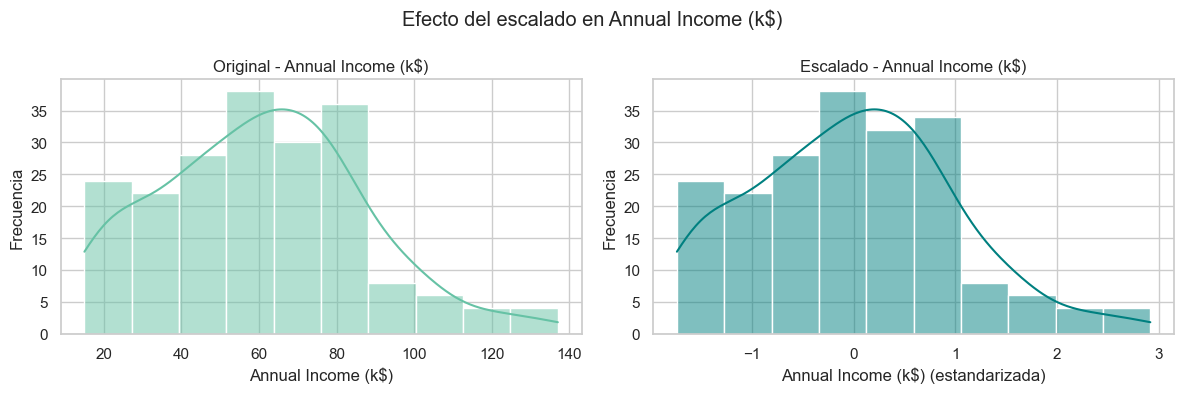

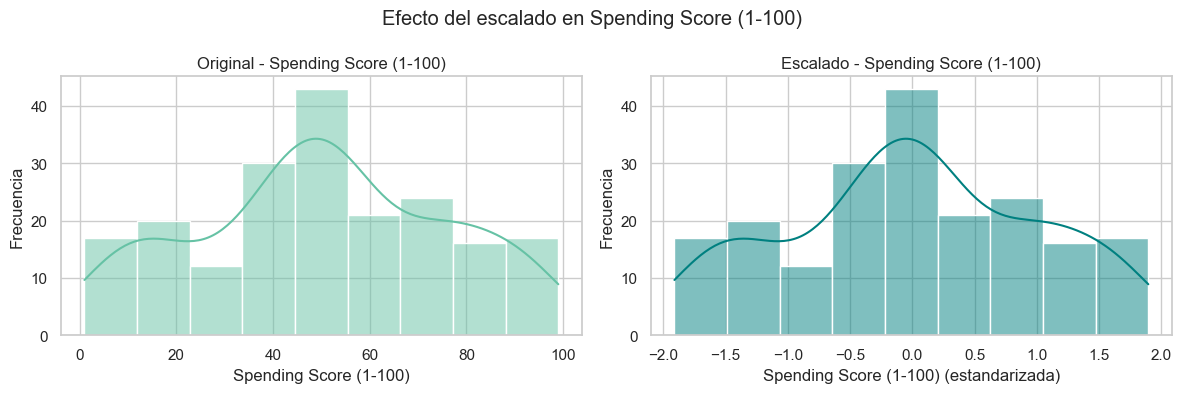

In [24]:
# Selección de variables finales para clustering
# Se priorizan variables de comportamiento económico y de consumo
selected_features = [c for c in ["Annual Income (k$)", "Spending Score (1-100)"] if c in df.columns]

# Si no existen esos nombres exactos, se usan las primeras variables numéricas disponibles
if len(selected_features) < 2:
    selected_features = numeric_cols[:2]

print("Variables seleccionadas para clustering:", selected_features)

# Matriz de entrada
X = df[selected_features].copy()

# Escalado de variables para homogeneizar magnitudes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features, index=df.index)

# Comparación antes y después de escalar
comparison = pd.concat([X.head(10).reset_index(drop=True), X_scaled_df.head(10).reset_index(drop=True)], axis=1, keys=["Original", "Escalado"])
display(comparison)

# Distribuciones originales vs escaladas
for col in selected_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(X[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Original - {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")

    sns.histplot(X_scaled_df[col], kde=True, ax=axes[1], color="teal")
    axes[1].set_title(f"Escalado - {col}")
    axes[1].set_xlabel(f"{col} (estandarizada)")
    axes[1].set_ylabel("Frecuencia")

    plt.suptitle(f"Efecto del escalado en {col}")
    plt.tight_layout()
    plt.show()

### Respuesta - Parte 2

**¿Por qué es necesario escalar en K-Means?**  
K-Means calcula distancias euclidianas, así que una variable con valores grandes domina el agrupamiento si no se escala. Por ejemplo, una diferencia de 60 en ingreso aporta `60²=3600`, mientras una diferencia de 10 en score aporta `10²=100`; sin escalado, ingreso pesa mucho más. Con `StandardScaler`, todas las variables quedan en escala comparable y contribuyen de forma equilibrada al clustering.

## PARTE 3 - Método del Codo

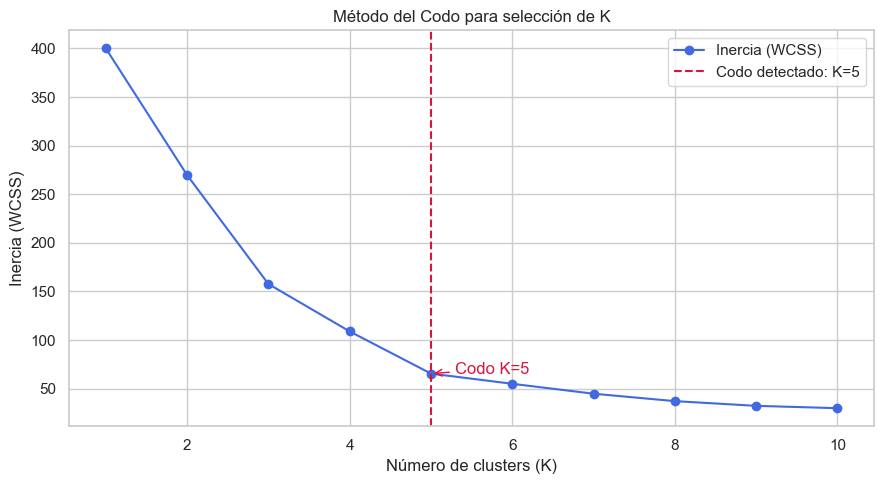

K sugerido por codo (kneed): 5


In [25]:
# Iteración sobre distintos K para calcular inercia (WCSS)
K_range = list(range(1, 11))
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Gráfica del codo
plt.figure(figsize=(9, 5))
plt.plot(K_range, inertias, marker="o", color="royalblue", label="Inercia (WCSS)")
plt.title("Método del Codo para selección de K")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (WCSS)")

# Detección automática opcional del codo con kneed
elbow_k = None
if KNEED_AVAILABLE:
    kneedle = KneeLocator(K_range, inertias, curve="convex", direction="decreasing")
    elbow_k = kneedle.elbow

if elbow_k is not None:
    plt.axvline(elbow_k, color="crimson", linestyle="--", label=f"Codo detectado: K={elbow_k}")
    plt.annotate(f"Codo K={elbow_k}", xy=(elbow_k, inertias[elbow_k-1]), xytext=(elbow_k+0.3, inertias[elbow_k-1]),
                 arrowprops=dict(arrowstyle="->", color="crimson"), color="crimson")

plt.legend()
plt.tight_layout()
plt.show()

print("K sugerido por codo (kneed):", elbow_k if elbow_k is not None else "No detectado automáticamente")

### Respuestas - Parte 3

**1) ¿Por qué valores cercanos a cero indican mejor ajuste?**  
La inercia mide la suma de distancias cuadradas entre cada punto y su centroide. Mientras menor sea, más compactos son los clusters. Sin embargo, reducirla en exceso aumentando K puede sobre-segmentar (caso extremo: `K=N`).

**2) ¿Cómo se identifica el punto óptimo de K?**  
Se busca el “codo” de la curva: el punto donde agregar más clusters ya no reduce la inercia de forma importante. Como este criterio puede ser subjetivo, se complementa con silueta para una decisión más robusta.

## PARTE 4 - Coeficiente de Silueta

,K,Silhouette
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


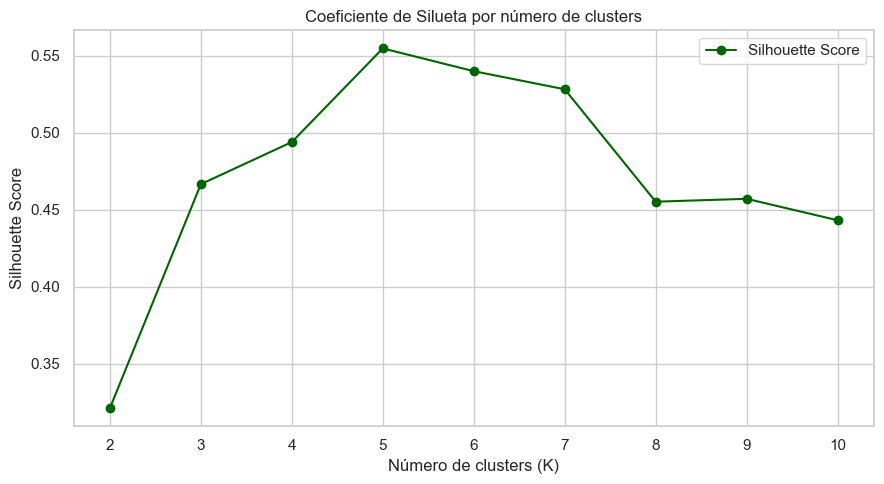

K con mejor silueta: 5
Mejor score de silueta: 0.5547


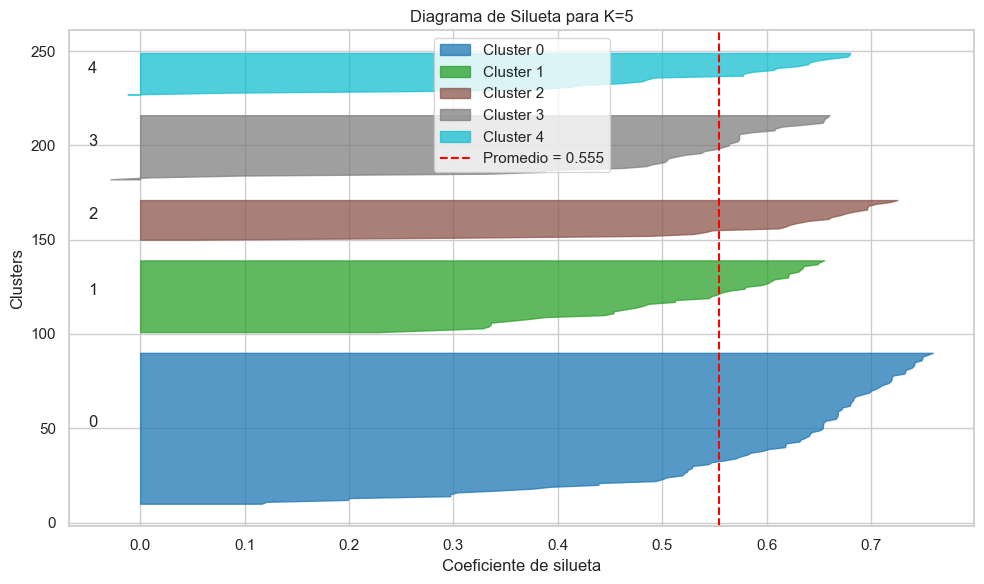

In [26]:
# Cálculo de silhouette_score para K entre 2 y 10
silhouette_scores = []
K_sil = list(range(2, 11))

for k in K_sil:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(s)

# Tabla de silueta por K (orden similar al notebook de referencia)
silhouette_df = pd.DataFrame({"K": K_sil, "Silhouette": silhouette_scores})
display(silhouette_df)

# Visualización de score de silueta por K
plt.figure(figsize=(9, 5))
plt.plot(K_sil, silhouette_scores, marker="o", color="darkgreen", label="Silhouette Score")
plt.title("Coeficiente de Silueta por número de clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

# Selección de K óptimo por máxima silueta
best_k_silhouette = int(silhouette_df.loc[silhouette_df["Silhouette"].idxmax(), "K"])
best_silhouette = float(silhouette_df["Silhouette"].max())
print("K con mejor silueta:", best_k_silhouette)
print(f"Mejor score de silueta: {best_silhouette:.4f}")

# Diagrama de silueta para el K óptimo
km_best = KMeans(n_clusters=best_k_silhouette, init="k-means++", n_init=10, random_state=RANDOM_STATE)
labels_best = km_best.fit_predict(X_scaled)
sil_samples = silhouette_samples(X_scaled, labels_best)
sil_avg = silhouette_score(X_scaled, labels_best)

plt.figure(figsize=(10, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, best_k_silhouette))

for i in range(best_k_silhouette):
    vals = sil_samples[labels_best == i]
    vals.sort()
    size_i = vals.shape[0]
    y_upper = y_lower + size_i

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=colors[i], edgecolor=colors[i], alpha=0.75, label=f"Cluster {i}")
    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

plt.axvline(sil_avg, color="red", linestyle="--", label=f"Promedio = {sil_avg:.3f}")
plt.title(f"Diagrama de Silueta para K={best_k_silhouette}")
plt.xlabel("Coeficiente de silueta")
plt.ylabel("Clusters")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

### Respuestas - Parte 4

**1) ¿Qué mide el coeficiente de silueta?**  
Cohesión dentro del cluster vs proximidad a clusters vecinos (qué tan bien asignados están los puntos).

**2) ¿Qué significa un valor cercano a 1?**  
Clusters bien separados internamente respecto del cluster siguiente más cercano.

**3) ¿Qué implica un valor cercano a 0 o negativo?**  
Cerca de `0`: mucho solapamiento. Negativo: posible mal asignación al cluster actual.

**4) ¿Coincide el K óptimo con el método del codo? Justifique.**  
Se compara el K del mayor `Silhouette` con una K marcada como codo (visual o por `elbow_k` si existe). Si coinciden, hay evidencia estable; si distan, se suele favorecer la mejor silueta y validar interpretación de negocio y tamaño de cada segmento.

## PARTE 5 - Entrenamiento del modelo final

In [27]:
# Parte 5 — Modelo final (KMeans)
if 'elbow_k' in globals() and elbow_k is not None:
    k_opt = best_k_silhouette if abs(best_k_silhouette - elbow_k) <= 1 else best_k_silhouette
else:
    k_opt = best_k_silhouette

print("K óptimo usado:", k_opt)

kmeans_final = KMeans(n_clusters=k_opt, init="k-means++", n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans_final.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered["Cluster"] = cluster_labels

print("Conteo por cluster:")
print(df_clustered["Cluster"].value_counts().sort_index())

centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=selected_features)
centroids_df["Cluster"] = centroids_df.index
centroids_df = centroids_df[["Cluster"] + selected_features].sort_values("Cluster").reset_index(drop=True)

print("\nCentroides en escala original:")
display(centroids_df)

K óptimo usado: 5
Conteo por cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Centroides en escala original:


,Cluster,Annual Income (k$),Spending Score (1-100)
0,0,55.296296,49.518519
1,1,86.538462,82.128205
2,2,25.727273,79.363636
3,3,88.200000,17.114286
4,4,26.304348,20.913043


## PARTE 6 - Visualización de clusters

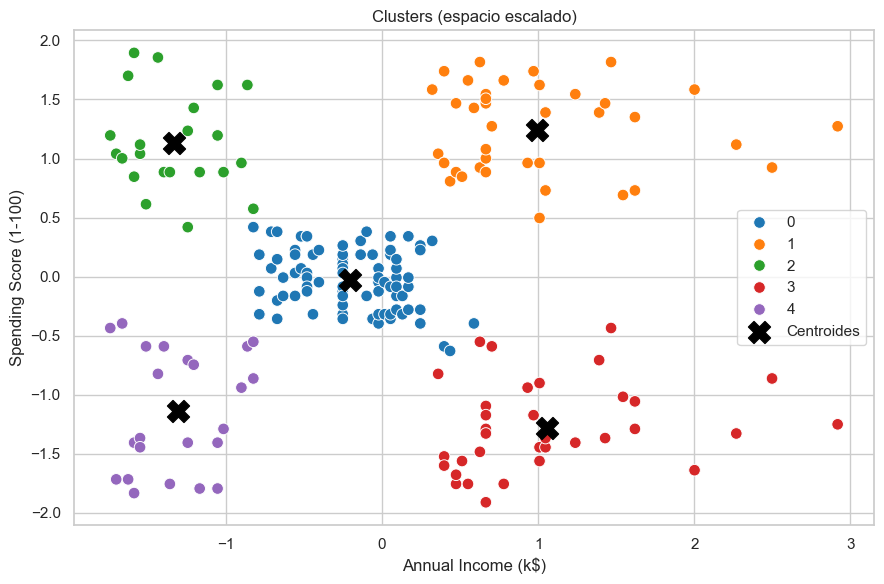

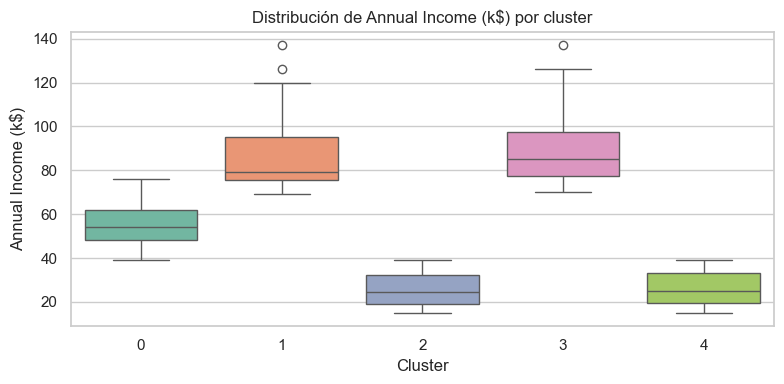

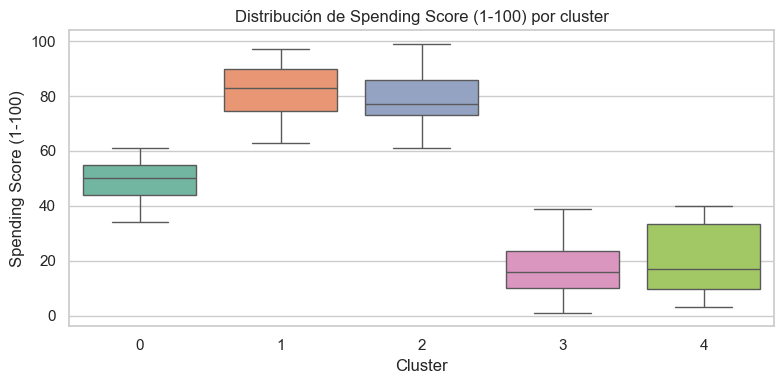

In [28]:
# Parte 6 — Visualización de clusters
plot_df = pd.DataFrame(X_scaled, columns=selected_features).copy()
plot_df["Cluster"] = cluster_labels

if len(selected_features) == 2:
    x_name, y_name = selected_features
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_df, x=x_name, y=y_name, hue="Cluster", palette="tab10", s=70)
    plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], marker="X", s=250, c="black", label="Centroides")
    plt.title("Clusters (espacio escalado)")
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
    plot_df["Cluster"] = cluster_labels
    centroids_pca = pca.transform(centroids_scaled)
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="tab10", s=70)
    plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=250, c="black", label="Centroides")
    plt.title("Clusters (PCA 2 componentes)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

for col in selected_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_clustered, x="Cluster", y=col, hue="Cluster", palette="Set2", legend=False)
    plt.title(f"Distribución de {col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


## PARTE 7 - Interpretación de negocio

Mapa rápido (según ingreso y Spending Score relativos):

- **Clientes de alto valor**: combinaciones altas en ambos.
- **Clientes promedio**: valores cercanos al “centro” de los centroides observados (ni extremos alto ni extremos bajo).
- **Clientes de bajo valor**: ambos relativamente bajos.
- **Clientes con potencial**: típicamente **alta capacidad económica y gasto bajo/medio**, o combinaciones donde el aumento del ticket tiene coste de persuasión bajo.

In [29]:
# Tabla por cluster y etiquetas desde centroides (originales)
centroids_business = centroids_df.copy()

income_col = selected_features[0]
score_col = selected_features[1] if len(selected_features) > 1 else selected_features[0]

income_q1, income_q3 = centroids_business[income_col].quantile([0.25, 0.75])
score_q1, score_q3 = centroids_business[score_col].quantile([0.25, 0.75])

def name_cluster(row):
    income = row[income_col]
    score = row[score_col]
    if income >= income_q3 and score >= score_q3:
        return "Clientes premium"
    if income >= income_q3 and score <= score_q1:
        return "Alto ingreso, bajo gasto"
    if income <= income_q1 and score >= score_q3:
        return "Jóvenes impulsivos"
    if income <= income_q1 and score <= score_q1:
        return "Bajo ingreso, bajo gasto"
    return "Segmento intermedio"


cluster_names = {int(row["Cluster"]): name_cluster(row) for _, row in centroids_business.iterrows()}
df_clustered["Segmento"] = df_clustered["Cluster"].map(cluster_names)

summary_table = (
    df_clustered.groupby(["Cluster", "Segmento"], as_index=False)
    .agg(Tamaño=("Cluster", "count"), Ingreso_promedio=(income_col, "mean"), Score_promedio=(score_col, "mean"))
    .sort_values(["Ingreso_promedio", "Score_promedio"], ascending=False)
    .reset_index(drop=True)
)

strategy_map = {
    "Clientes premium": "Retención VIP + upselling alto margen",
    "Alto ingreso, bajo gasto": "CRM personalizado + bundles de activación",
    "Jóvenes impulsivos": "Promociones flash + fidelidad gamificada",
    "Bajo ingreso, bajo gasto": "Ofertas de entrada + cupones de recurrencia",
    "Segmento intermedio": "Cross-selling + nurturing email",
}

summary_table["Estrategia"] = summary_table["Segmento"].map(strategy_map)
summary_table = summary_table[
    ["Cluster", "Segmento", "Tamaño", "Ingreso_promedio", "Score_promedio", "Estrategia"]
]

print("Tabla resumen:")
display(summary_table)


Tabla resumen:


,Cluster,Segmento,Tamaño,Ingreso_promedio,Score_promedio,Estrategia
0,3,"Alto ingreso, bajo gasto",35,88.200000,17.114286,CRM personalizado + bundles de activación
1,1,Clientes premium,39,86.538462,82.128205,Retención VIP + upselling alto margen
2,0,Segmento intermedio,81,55.296296,49.518519,Cross-selling + nurturing email
3,4,"Bajo ingreso, bajo gasto",23,26.304348,20.913043,Ofertas de entrada + cupones de recurrencia
4,2,Jóvenes impulsivos,22,25.727273,79.363636,Promociones flash + fidelidad gamificada


### Respuestas - Parte 7

**1) ¿Qué estrategias se podrían aplicar por grupo?**  
- Alto valor (`Clientes premium`): beneficios VIP, lanzamientos anticipados y bundles premium.  
- Promedio / intermedio: bundles y comunicación recurrente pero no intensiva promociones.  
- Bajo valor: cupones escalonados y onboarding barato desde digital.  
- Con potencial (`Alto ingreso, bajo gasto`): rutas guiadas upsell demo de categorías clave antes de grandes descuentos.

**2) ¿Qué segmento representa mayor oportunidad de crecimiento?**  
Suele ser **con potencial** (aquí cercano a alto ingreso y gasto medio-bajo), porque aumentar share of wallet tiene impacto rápido al no requerir campañas de adquisición.

**¿Nombres de clusters?**  
Se generan desde la tabla anterior según centroides relativos.

## PARTE 8 - Despliegue con Streamlit (fuera del notebook)

En esta parte, el despliegue **no se ejecuta dentro del cuaderno**. El notebook solo deja el modelo exportado y la guía para levantar la aplicación externa.

Pasos:
1. Ejecutar la celda de exportación para generar `kmeans_mall_customers.joblib`.
2. Ejecutar en terminal: `streamlit run streamlit_app.py`.
3. Usar la app para visualizar codo, clusters y clasificar un nuevo cliente.

Código de arranque en terminal:

```bash
streamlit run streamlit_app.py
```

In [30]:
# Parte 8 — Exportación a joblib para Streamlit (no se ejecuta la app dentro del notebook)
bundle_model = {
    "model": kmeans_final,
    "scaler": scaler,
    "features": selected_features,
    "k": int(k_opt),
    "cluster_names": cluster_names,
    "strategy_map": strategy_map,
    "centroids_original": centroids_df.to_dict(orient="records"),
    "k_values_elbow": K_range if "K_range" in globals() else None,
    "inertias_elbow": inertias if "inertias" in globals() else None,
}

joblib.dump(bundle_model, "kmeans_mall_customers.joblib")
print("Guardado:", "kmeans_mall_customers.joblib")
print("Terminal: streamlit run streamlit_app.py")


Guardado: kmeans_mall_customers.joblib
Terminal: streamlit run streamlit_app.py


## Conclusiones generales

Este cuaderno mostró cómo llevar clustering K-Means desde exploración hasta un artefacto reutilizable. El escalado y la combinación método del codo + silueta dan una decisión de `K` defendible ante negocio. Los centroides en escala original traducen el modelo a estrategias concretas.

El despliegue queda fuera del notebook: tras exportar `.joblib`, la app Streamlit permite monitorear el codo/clusters y clasificar un nuevo cliente con la misma lógica de features y scaler.

Las métricas de silueta (y su forma en porcentaje en la siguiente sección) resumen compactación/separación, recordando que no existen etiquetas verdaderas de “accuracy supervisada”.


## Evaluación del modelo — silueta (no hay accuracy supervisada)

En clustering no hay etiquetas reales contra las cuales medir precision/recall tipo clasificación supervisada.

Se usa **silhouette score** sobre las asignaciones finales como indicador externo útil tras elegir `K`:

`calidad_pct = ((silhouette + 1) / 2) * 100` es sólo interpretación tipo “0–100%” de ese score, **no equivalencia estadística exacta**.


In [31]:
# Silueta sobre el modelo final + conversión tipo porcentaje
sil_final = silhouette_score(X_scaled, cluster_labels)
pct = ((sil_final + 1) / 2) * 100

print(f"Silueta modelo final (K={k_opt}): {sil_final:.4f}")
print(f"Indicador 0–100% (solo transformación): {pct:.2f}%")

if sil_final >= 0.55:
    print("Interpretación: separación/cohesión alta para este dataset corto.")
elif sil_final >= 0.35:
    print("Interpretación: aceptable pero revisar outliers o segunda variable extra.")
else:
    print("Interpretación: solapamiento notable.")


Silueta modelo final (K=5): 0.5547
Indicador 0–100% (solo transformación): 77.73%
Interpretación: separación/cohesión alta para este dataset corto.
